In [151]:
from qiskit import *
from qiskit_aer import AerSimulator, StatevectorSimulator
import numpy as np
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
import matplotlib.pyplot as plt

# Data generation

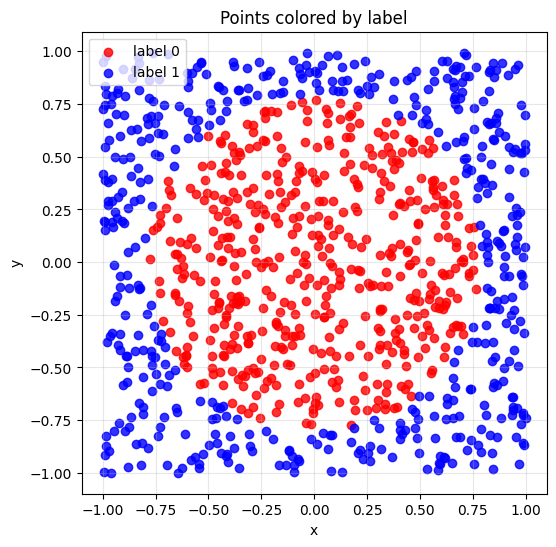

points in label 0: 504
points in label 1: 496


In [152]:
n = 1000
points = np.random.rand(n, 2) * 2 - 1
labels = [0 if x**2 + y**2 < 2/np.pi else 1 for x, y in points]


import matplotlib.pyplot as plt

arr = np.array(points)
lbl = np.array(labels)

plt.figure(figsize=(6, 6))
plt.scatter(arr[lbl == 0, 0], arr[lbl == 0, 1], c="red", label="label 0", alpha=0.8)
plt.scatter(arr[lbl == 1, 0], arr[lbl == 1, 1], c="blue", label="label 1", alpha=0.8)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Points colored by label")
plt.axis("equal")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("points in label 0:", np.sum(lbl == 0))
print("points in label 1:", np.sum(lbl == 1))

In [153]:

test_size = 0.2
rng = np.random.default_rng(42)

indices = rng.permutation(len(arr))
split_idx = int(len(arr) * (1 - test_size))

train_idx, test_idx = indices[:split_idx], indices[split_idx:]

X_train, X_test = arr[train_idx], arr[test_idx]
y_train, y_test = lbl[train_idx], lbl[test_idx]

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test :", X_test.shape, "y_test :", y_test.shape)

X_train: (800, 2) y_train: (800,)
X_test : (200, 2) y_test : (200,)


In [154]:
def U(q, theta, omega, x, qubit):
    wx = np.multiply(np.asarray(omega), np.asarray(x))  # Hadamard product
    q.rx(theta[0] + wx[0], qubit)
    q.rz(theta[1] + wx[1], qubit)

In [155]:
def U_su2(q, theta, omega, x, qubit):
    x3d = [x[0], x[1], 0] # Add a third dimension with value 0
    # phi_i = theta_i + w_i * x_i
    val_0 = theta[0] + omega[0] * x3d[0]
    val_1 = theta[1] + omega[1] * x3d[1]
    val_2 = theta[2] + omega[2] * x3d[2]
    
    q.u(val_0, val_1, val_2, qubit)

In [156]:
rc = 4

def create_circuit(x, theta, omega, measure=True):
    qc = QuantumCircuit(1)
    for i in range(rc):
        U_su2(qc, theta[i], omega[i], x, 0)
    if measure:
        qc.measure_all()
    return qc


In [157]:
theta = [[1,1,1] for _ in range(rc)]
omega = [[1,1,1] for _ in range(rc)]
qc =create_circuit(X_train[0], theta, omega)
qc.draw()

┌───────────────────┐┌───────────────────┐┌───────────────────┐»
     q: ┤ U(1.0129,1.898,1) ├┤ U(1.0129,1.898,1) ├┤ U(1.0129,1.898,1) ├»
        └───────────────────┘└───────────────────┘└───────────────────┘»
meas: 1/═══════════════════════════════════════════════════════════════»
                                                                       »
«        ┌───────────────────┐ ░ ┌─┐
«     q: ┤ U(1.0129,1.898,1) ├─░─┤M├
«        └───────────────────┘ ░ └╥┘
«meas: 1/═════════════════════════╩═
«                                 0

In [158]:
sv_sim = StatevectorSimulator()

def get_prob_zero(circuit):
    """
    Retourne la probabilité d'état |0⟩ via simulation statevector (pas de shots).
    """
    qc_no_meas = create_circuit.__wrapped__(circuit) if hasattr(create_circuit, '__wrapped__') else circuit
    sv = sv_sim.run(transpile(qc_no_meas, sv_sim)).result().get_statevector()
    return float(abs(sv[0])**2)

def cost_function(theta, omega, X_train, y_train):
    """
    Calcule le coût en batch : un seul transpile + run pour tous les points.
    """
    circuits = [create_circuit(x, theta, omega, measure=False) for x in X_train]
    compiled = transpile(circuits, sv_sim)
    results = sv_sim.run(compiled).result()

    total_cost = 0.0
    for i, y in enumerate(y_train):
        sv = results.get_statevector(i)
        prob_0 = float(abs(sv[0])**2)
        predicted_prob = prob_0 if y == 0 else (1 - prob_0)
        total_cost += (1 - predicted_prob)
    return total_cost / len(y_train)


In [159]:
def cost_function_weighted(params, X_train, y_train, rc):
    # 1. Extraction des paramètres (3*rc pour theta, 3*rc pour omega, 2 pour alpha)
    # On s'assure que rc est un entier
    rc = int(rc)
    split_theta = 3 * rc
    split_omega = 6 * rc
    
    theta = params[:split_theta].reshape(rc, 3)
    omega = params[split_theta:split_omega].reshape(rc, 3)
    alphas = params[split_omega:] # alpha_0 et alpha_1

    # 2. Simulation des circuits en batch (sans mesures pour le Statevector)
    circuits = [create_circuit(x, theta, omega, measure=False) for x in X_train]
    compiled = transpile(circuits, sv_sim)
    results = sv_sim.run(compiled).result()

    total_cost = 0.0
    for i, y_target in enumerate(y_train):
        # Récupération du vecteur d'état final |psi>
        sv = results.get_statevector(i)
        
        # Calcul des fidélités F_c = |<target_c|psi>|^2
        # Pour la classe 0 (Nord) : |<0|psi>|^2 = abs(sv[0])^2
        f0 = np.abs(sv.data[0])**2
        # Pour la classe 1 (Sud) : |<1|psi>|^2 = abs(sv[1])^2
        f1 = np.abs(sv.data[1])**2
        
        f_measures = [f0, f1]

        # Overlaps attendus Y_c (Eq. 247/248)
        # Classe cible = 1, Classe opposée = 0 (car orthogonales)
        y_expected = [1.0, 0.0] if y_target == 0 else [0.0, 1.0]

        # Somme pondérée (alpha_c * F_c - Y_c)^2
        sample_error = 0.0
        for c in range(2):
            sample_error += (alphas[c] * f_measures[c] - y_expected[c])**2
        
        total_cost += sample_error

    # 1/2 * moyenne (Eq. 9)
    return 0.5 * (total_cost / len(y_train))

In [160]:
import numpy as np
from scipy.optimize import minimize



def unpack_params(params, rc):
    split_theta = 3 * rc
    split_omega = 6 * rc
    theta = params[:split_theta].reshape(rc, 3)
    omega = params[split_theta:split_omega].reshape(rc, 3)
    alphas = params[split_omega:]
    return theta, omega, alphas

def objective(params, X_train, y_train, rc):
    theta, omega, alphas = unpack_params(params, rc)
    return cost_function_weighted(params, X_train, y_train,rc)



def optimize_parameters(X_train, y_train, rc, maxiter=80, seed=42):
        
    rng = np.random.default_rng(seed)
    init = rng.uniform(-np.pi, np.pi, size=6 * rc+2) # 3*rc pour theta, 3*rc pour omega, 2 pour alpha

    step = {"k": 0}
    def cb(xk):
        step["k"] += 1
        print(f"Step {step['k']:03d}")

    res = minimize(
        objective,
        init,
        args=(X_train, y_train, rc),
        method="COBYLA",
        callback=cb,
        options={"maxiter": maxiter}
    )

    theta_opt, omega_opt, alphas_opt = unpack_params(res.x, rc)
    print(f"Final cost = {res.fun:.6f}")
    return theta_opt, omega_opt, res

In [161]:
def predict_batch(X, theta, omega):
    """
    Prédit les labels pour tous les points X en un seul appel sim.run.
    """
    circuits = [create_circuit(x, theta, omega, measure=False) for x in X]
    compiled = transpile(circuits, sv_sim)
    results = sv_sim.run(compiled).result()
    preds = []
    for i in range(len(X)):
        sv = results.get_statevector(i)
        prob_0 = float(abs(sv[0])**2)
        preds.append(0 if prob_0 >= 0.5 else 1)
    return np.array(preds)

def evaluate_metrics(X, y, theta, omega, positive_label=1):
    y_pred = predict_batch(X, theta, omega)
    tp = np.sum((y_pred == positive_label) & (y == positive_label))
    fp = np.sum((y_pred == positive_label) & (y != positive_label))
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    accuracy = np.mean(y_pred == y)
    return precision, accuracy, y_pred

# --- train + test ---
theta_opt, omega_opt, res = optimize_parameters(X_train, y_train, rc, maxiter=300)
precision_test, accuracy_test, y_pred = evaluate_metrics(X_test, y_test, theta_opt, omega_opt)

print("Final train cost:", res.fun)
print("Test precision:", precision_test)
print("Test accuracy: ", accuracy_test)


Step 001
Step 002
Step 003
Step 004
Step 005
Step 006
Step 007
Step 008
Step 009
Step 010
Step 011
Step 012
Step 013
Step 014
Step 015
Step 016
Step 017
Step 018
Step 019
Step 020
Step 021
Step 022
Step 023
Step 024
Step 025
Step 026
Step 027
Step 028
Step 029
Step 030
Step 031
Step 032
Step 033
Step 034
Step 035
Step 036
Step 037
Step 038
Step 039
Step 040
Step 041
Step 042
Step 043
Step 044
Step 045
Step 046
Step 047
Step 048
Step 049
Step 050
Step 051
Step 052
Step 053
Step 054
Step 055
Step 056
Step 057
Step 058
Step 059
Step 060
Step 061
Step 062
Step 063
Step 064
Step 065
Step 066
Step 067
Step 068
Step 069
Step 070
Step 071
Step 072
Step 073
Step 074
Step 075
Step 076
Step 077
Step 078
Step 079
Step 080
Step 081
Step 082
Step 083
Step 084
Step 085
Step 086
Step 087
Step 088
Step 089
Step 090
Step 091
Step 092
Step 093
Step 094
Step 095
Step 096
Step 097
Step 098
Step 099
Step 100
Step 101
Step 102
Step 103
Step 104
Step 105
Step 106
Step 107
Step 108
Step 109
Step 110
Step 111
S

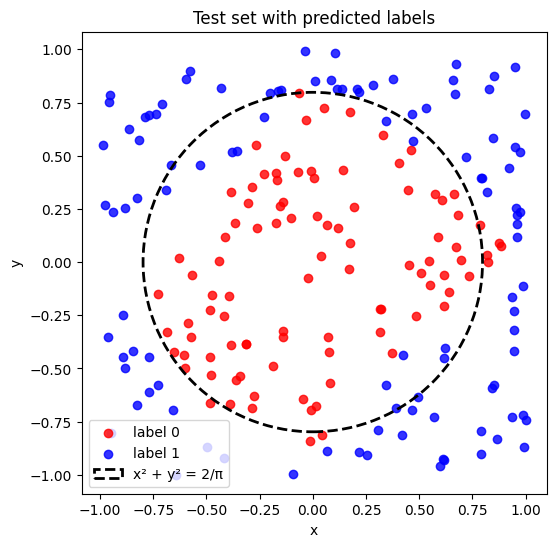

In [162]:
plt.figure(figsize=(6, 6))
plt.scatter(X_test[y_pred == 0][:, 0], X_test[y_pred == 0][:, 1], c="red", label="label 0", alpha=0.8)
plt.scatter(X_test[y_pred == 1][:, 0], X_test[y_pred == 1][:, 1], c="blue", label="label 1", alpha=0.8)
r = np.sqrt(2 / np.pi)
circle = plt.Circle((0, 0), r, color="black", fill=False, linestyle="--", linewidth=2, label="x² + y² = 2/π")
plt.gca().add_patch(circle)
plt.axis("equal")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Test set with predicted labels")
plt.legend()
plt.show()